In [2]:
import pandas as pd

In [3]:
licznik = pd.read_excel('LicznikCiepła.xlsx')

In [4]:
licznik = pd.read_excel('LicznikCiepła.xlsx')
print(licznik['UNIT_DATE'].head(10))

0   2023-02-01 23:55:00
1   2023-02-01 22:55:00
2   2023-02-01 21:55:00
3   2023-02-01 20:55:00
4   2023-02-01 19:55:00
5   2023-02-01 18:55:00
6   2023-02-01 17:55:00
7   2023-02-01 16:55:00
8   2023-02-01 15:55:00
9   2023-02-01 14:55:00
Name: UNIT_DATE, dtype: datetime64[ns]


In [5]:
licznik = licznik.sort_values('UNIT_DATE').reset_index(drop=True)

In [6]:
#Obliczenie zużycia ciepła jako różnicy kolejnych wartości ThermalEnergy
licznik['Zużycie'] = licznik ['ThermalEnergy'].diff()

In [7]:
#Usunięcie pierwszego wiersza, gdzie diff() zwróci NaN
licznik = licznik.dropna(subset=['Zużycie']).reset_index(drop=True)

In [8]:
licznik.head()

,UNIT_DATE,VolumeWM1,VolumeWM2,ThermalEnergy,Volume,Power,FlowVolume,SourceTemp,ReturnTemp,TempDifference,Zużycie
0,2019-01-01 01:55:00,0.4,0,5792.1,39395.8,68.5,1468,82.17,40.79,41.38,0.3
1,2019-01-01 02:55:00,0.4,0,5792.4,39397.8,124.2,2836,82.96,44.11,38.85,0.3
2,2019-01-01 03:55:00,0.4,0,5792.7,39400.1,50.8,1238,83.55,47.12,36.43,0.3
3,2019-01-01 04:55:00,0.4,0,5793.0,39401.9,80.5,1994,81.41,45.64,35.77,0.3
4,2019-01-01 05:55:00,0.4,0,5793.3,39403.9,90.9,2088,81.12,42.53,38.59,0.3


In [9]:
pogoda = pd.read_excel('Pogoda_gdańsk_wykonanie.xlsx')

In [10]:
pogoda.rename(columns={pogoda.columns[0]: 'DATA_GODZINA'}, inplace=True)

In [11]:
print(pogoda.columns)

Index(['DATA_GODZINA', 'Wartości godzinowe dla stacji Port Północny/Świbno',
       'Unnamed: 2', 'Unnamed: 3', 'Wartości godzinowe dla stacji Rębiechowo',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')


In [12]:
#Wczytujemy plik, pomijajc pierwsze trzy wiersze 
pogoda = pd.read_excel("Pogoda_gdańsk_wykonanie.xlsx", skiprows=3)


In [13]:
# Nadajemy nowe, czytelne nagłówki
pogoda.columns = [
    "DATA_GODZINA",      # kolumna A
    "Temp_Swibno",       # kolumna B
    "Wiatr_Swibno",      # kolumna C
    "Słońce_Swibno",     # kolumna D
    "Temp_Rebiechowo",   # kolumna E
    "Wiatr_Rebiechowo",  # kolumna F
    "Słońce_Rebiechowo", # kolumna G
    "Temp_Średnia"       # kolumna H
]


In [14]:
# Wybieramy tylko datę i średnią temperaturę
pogoda = pogoda[["DATA_GODZINA", "Temp_Średnia"]].copy()
pogoda.columns = ["UNIT_DATE", "TempZew"]  # dopasowanie do licznika


In [15]:
dane = pd.merge(licznik, pogoda, on="UNIT_DATE", how="inner")

In [16]:
dane.head()

,UNIT_DATE,VolumeWM1,VolumeWM2,ThermalEnergy,Volume,Power,FlowVolume,SourceTemp,ReturnTemp,TempDifference,Zużycie,TempZew


In [17]:
licznik = licznik.sort_values("UNIT_DATE")
pogoda = pogoda.sort_values("UNIT_DATE")

In [18]:
dane = pd.merge_asof(
    licznik,
    pogoda,
    on="UNIT_DATE",
    direction="nearest",  
    tolerance=pd.Timedelta("10min")  # dopasowanie jeśli godziny różnią się minimalnie
)

In [19]:
dane = dane.dropna(subset=["TempZew"])

In [20]:
dane.head()

,UNIT_DATE,VolumeWM1,VolumeWM2,ThermalEnergy,Volume,Power,FlowVolume,SourceTemp,ReturnTemp,TempDifference,Zużycie,TempZew
0,2019-01-01 01:55:00,0.4,0,5792.1,39395.8,68.5,1468,82.17,40.79,41.38,0.3,4.15
1,2019-01-01 02:55:00,0.4,0,5792.4,39397.8,124.2,2836,82.96,44.11,38.85,0.3,4.60
2,2019-01-01 03:55:00,0.4,0,5792.7,39400.1,50.8,1238,83.55,47.12,36.43,0.3,5.00
3,2019-01-01 04:55:00,0.4,0,5793.0,39401.9,80.5,1994,81.41,45.64,35.77,0.3,5.70
4,2019-01-01 05:55:00,0.4,0,5793.3,39403.9,90.9,2088,81.12,42.53,38.59,0.3,5.80


In [21]:
dane = dane[["UNIT_DATE", "Zużycie", "TempZew"]].copy()

In [22]:
dane.head()

,UNIT_DATE,Zużycie,TempZew
0,2019-01-01 01:55:00,0.3,4.15
1,2019-01-01 02:55:00,0.3,4.60
2,2019-01-01 03:55:00,0.3,5.00
3,2019-01-01 04:55:00,0.3,5.70
4,2019-01-01 05:55:00,0.3,5.80


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
sns.set(style="whitegrid")


In [25]:
godzinowe = dane.copy()


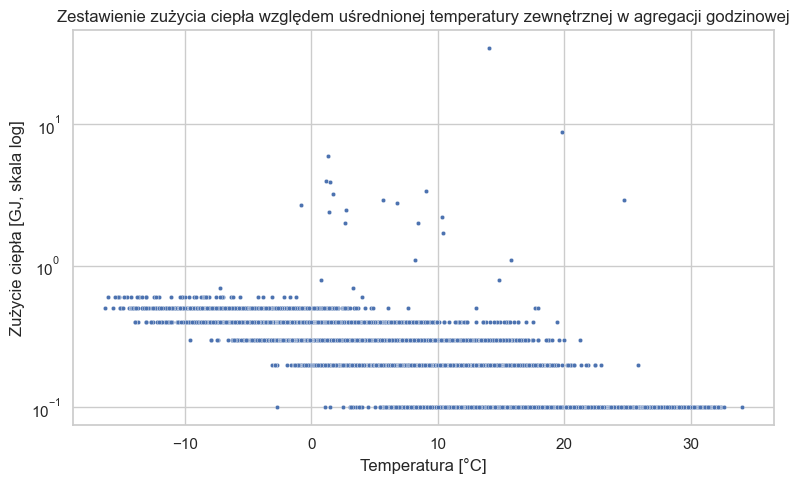

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=godzinowe, x="TempZew", y="Zużycie", s=10)
plt.yscale("log")  
plt.title("Zestawienie zużycia ciepła względem uśrednionej temperatury zewnętrznej w agregacji godzinowej")
plt.xlabel("Temperatura [°C]")
plt.ylabel("Zużycie ciepła [GJ, skala log]")
plt.tight_layout()

#plt.savefig("agr_godzinowa_wykres.png", dpi=300)
plt.show()

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=dobowe, x="TempZew", y="Zużycie", s=20)
plt.yscale("log")
plt.title("Zestawienie zużycia ciepła względem uśrednionej temperatury zewnętrznej w agregacji dobowej")
plt.xlabel("Średnia dobowa temperatura [°C]")
plt.ylabel("Dobowe zużycie ciepła [GJ]")
plt.tight_layout()

#plt.savefig("agr_dobowa_wykres.png", dpi=300)
plt.show()

NameError: name 'dobowe' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# Tworzymy kolumny rok i miesiąc
dane["Rok"] = dane["UNIT_DATE"].dt.year
dane["Miesiąc"] = dane["UNIT_DATE"].dt.month

# Grupowanie miesięczne
miesięczne = dane.groupby(["Rok", "Miesiąc"]).agg({
    "Zużycie": "sum",
    "TempZew": "mean"
}).reset_index()

# Wykres miesięczny
plt.figure(figsize=(8,5))
sns.scatterplot(data=miesięczne, x="TempZew", y="Zużycie", s=50)
plt.yscale("log")
plt.title("Zestawienie zużycia ciepła względem uśrednionej temperatury zewnętrznej w agregacji miesięcznej")
plt.xlabel("Średnia miesięczna temperatura [°C]")
plt.ylabel("Miesięczne zużycie ciepła [GJ]")
plt.tight_layout()

#plt.savefig("agr_miesięczna_wykres.png", dpi=300)
plt.show()

In [ ]:
dane_2020 = dane[dane["UNIT_DATE"].dt.year == 2020].copy()

In [ ]:
dane_2020["Miesiąc"] = dane_2020["UNIT_DATE"].dt.month

In [ ]:
zuzycie_2020 = dane_2020.groupby("Miesiąc")["Zużycie"].sum().reset_index()

In [ ]:
zuzycie_2020.columns = ["Miesiąc", "Zużycie"]

In [ ]:
zuzycie_2020.head()

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=zuzycie_2020, x="Miesiąc", y="Zużycie", palette="Blues_d")
plt.title("Sumaryczne zużycie ciepła w 2020 roku")
plt.xlabel("Miesiąc")
plt.ylabel("Zużycie ciepła [GJ]")
plt.xticks(ticks=range(0,12), labels = ["Styczeń", "Luty", "Marzec", "Kwiecień", "Maj", "Czerwiec", "Lipiec", "Sierpień", "Wrzesień", "Październik", "Listopad", "Grudzień"], rotation=45)
plt.tight_layout()

#plt.savefig("ciepło2020_wykres.png", dpi=300)
plt.show()

In [ ]:
with pd.ExcelWriter("wyniki_zestawień.xlsx") as writer:
    godzinowe.to_excel(writer, sheet_name="Godzinowe", index=False)
    dobowe.to_excel(writer, sheet_name="Dobowe", index=False)
    miesięczne.to_excel(writer, sheet_name="Miesięczne", index=False)
    zuzycie_2020.to_excel(writer, sheet_name="Zużycie 2020", index=False)

In [ ]:
import pickle

In [ ]:
with open("wyniki_zestawień.pkl", "wb") as f:
    pickle.dump(dane, f)

In [ ]:
with open("wyniki_zestawień.pkl", "rb") as f:
    dane_test = pickle.load(f)

In [ ]:
dane_test.head()